# Exploratory Data Analysis on Cars Dataset

### Minor Project

**Dataset:** Car Details v3.csv  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Platform:** Google Colab

## 1. Import Libraries

In [54]:
from google.colab import files

uploaded = files.upload()

Saving Car details v3.csv to Car details v3 (2).csv


## 2. Load Dataset

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Dataset Overview

In [56]:
df = pd.read_csv("Car details v3.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 4. Data Quality Analysis

In [57]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 5. Data Cleaning

In [58]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8128
Number of columns: 13


In [59]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [61]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


In [62]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1202


In [63]:
for column in df.select_dtypes(include='object').columns:
    print("\n", column)
    print(df[column].unique())


 name
['Maruti Swift Dzire VDI' 'Skoda Rapid 1.5 TDI Ambition'
 'Honda City 2017-2020 EXi' ... 'Tata Nexon 1.5 Revotorq XT'
 'Ford Freestyle Titanium Plus Diesel BSIV'
 'Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV']

 fuel
['Diesel' 'Petrol' 'LPG' 'CNG']

 seller_type
['Individual' 'Dealer' 'Trustmark Dealer']

 transmission
['Manual' 'Automatic']

 owner
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']

 mileage
['23.4 kmpl' '21.14 kmpl' '17.7 kmpl' '23.0 kmpl' '16.1 kmpl' '20.14 kmpl'
 '17.3 km/kg' '23.59 kmpl' '20.0 kmpl' '19.01 kmpl' '17.3 kmpl'
 '19.3 kmpl' nan '18.9 kmpl' '18.15 kmpl' '24.52 kmpl' '19.7 kmpl'
 '22.54 kmpl' '21.0 kmpl' '25.5 kmpl' '26.59 kmpl' '21.5 kmpl' '20.3 kmpl'
 '21.4 kmpl' '24.7 kmpl' '18.2 kmpl' '16.8 kmpl' '24.3 kmpl' '14.0 kmpl'
 '18.6 kmpl' '33.44 km/kg' '23.95 kmpl' '17.0 kmpl' '20.63 kmpl'
 '13.93 kmpl' '16.0 kmpl' '17.8 kmpl' '18.5 kmpl' '12.55 kmpl'
 '12.99 kmpl' '14.8 kmpl' '13.5 kmpl' '26.0 kmpl' '20.65 kmpl'

In [64]:
# Store original dataset information

original_rows = df.shape[0]
original_columns = df.shape[1]

print("Before Cleaning")
print("Rows:", original_rows)
print("Columns:", original_columns)
print("Duplicate Rows:", df.duplicated().sum())

Before Cleaning
Rows: 8128
Columns: 13
Duplicate Rows: 1202


In [65]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


In [66]:
clean_df = df.drop_duplicates().copy()

print("Rows after removing duplicates:", clean_df.shape[0])

Rows after removing duplicates: 6926


In [67]:
clean_df['mileage_value'] = (
    clean_df['mileage']
    .astype(str)
    .str.extract(r'([\d.]+)')[0]
    .astype(float)
)

print(clean_df[['mileage', 'mileage_value']].head())

      mileage  mileage_value
0   23.4 kmpl          23.40
1  21.14 kmpl          21.14
2   17.7 kmpl          17.70
3   23.0 kmpl          23.00
4   16.1 kmpl          16.10


In [68]:
clean_df['engine_cc'] = (
    clean_df['engine']
    .astype(str)
    .str.extract(r'([\d.]+)')[0]
    .astype(float)
)

print(clean_df[['engine', 'engine_cc']].head())

    engine  engine_cc
0  1248 CC     1248.0
1  1498 CC     1498.0
2  1497 CC     1497.0
3  1396 CC     1396.0
4  1298 CC     1298.0


In [69]:
clean_df['max_power_bhp'] = (
    clean_df['max_power']
    .astype(str)
    .str.extract(r'([\d.]+)')[0]
    .astype(float)
)

print(clean_df[['max_power', 'max_power_bhp']].head())

    max_power  max_power_bhp
0      74 bhp          74.00
1  103.52 bhp         103.52
2      78 bhp          78.00
3      90 bhp          90.00
4    88.2 bhp          88.20


In [70]:
current_year = 2026

clean_df['vehicle_age'] = current_year - clean_df['year']

print(clean_df[['year', 'vehicle_age']].head())

   year  vehicle_age
0  2014           12
1  2014           12
2  2006           20
3  2010           16
4  2007           19


In [71]:
print(clean_df.dtypes)

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
mileage_value    float64
engine_cc        float64
max_power_bhp    float64
vehicle_age        int64
dtype: object


In [72]:
print("Missing values in important numerical columns:")
print(clean_df[['mileage_value', 'engine_cc', 'max_power_bhp', 'seats']].isnull().sum())

Missing values in important numerical columns:
mileage_value    208
engine_cc        208
max_power_bhp    206
seats            208
dtype: int64


In [73]:
numeric_columns = [
    'mileage_value',
    'engine_cc',
    'max_power_bhp',
    'seats'
]

for column in numeric_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

print("Missing values after treatment:")
print(clean_df[numeric_columns].isnull().sum())

Missing values after treatment:
mileage_value    0
engine_cc        0
max_power_bhp    0
seats            0
dtype: int64


In [74]:
print("Final Dataset Information")
print("-------------------------")

print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

print("\nMissing Values:")
print(clean_df.isnull().sum())

Final Dataset Information
-------------------------
Rows: 6926
Columns: 17

Missing Values:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        205
torque           209
seats              0
mileage_value      0
engine_cc          0
max_power_bhp      0
vehicle_age        0
dtype: int64


In [75]:
final_rows = clean_df.shape[0]

print("DATA CLEANING SUMMARY")
print("=====================")
print("Original rows:", original_rows)
print("Duplicate rows removed:", original_rows - final_rows)
print("Final rows:", final_rows)
print("Original columns:", original_columns)
print("Final columns:", clean_df.shape[1])

DATA CLEANING SUMMARY
Original rows: 8128
Duplicate rows removed: 1202
Final rows: 6926
Original columns: 13
Final columns: 17


### Missing Value Treatment

Missing values were present in the original text-based attributes such as mileage, engine, maximum power and torque. For numerical analysis, analysis-ready variables were created from mileage, engine and maximum power, and their missing numerical values were replaced using the median of the corresponding variable. The original text columns were retained for reference.

## 6. Descriptive Statistics

In [76]:
# Descriptive statistics for numerical variables

clean_df.describe()

,year,selling_price,km_driven,seats,mileage_value,engine_cc,max_power_bhp,vehicle_age
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,5.421600,19.464550,1425.398787,87.551527,12.579700
std,4.078286,5.197670e+05,5.835810e+04,0.972171,3.987878,487.026967,31.311523,4.078286
min,1983.000000,2.999900e+04,1.000000e+00,2.000000,0.000000,624.000000,0.000000,6.000000
25%,2011.000000,2.500000e+05,4.000000e+04,5.000000,16.950000,1197.000000,68.000000,9.000000
50%,2014.000000,4.000000e+05,7.000000e+04,5.000000,19.440000,1248.000000,81.830000,12.000000
75%,2017.000000,6.335000e+05,1.000000e+05,5.000000,22.320000,1498.000000,99.000000,15.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000,42.000000,3604.000000,400.000000,43.000000


In [77]:
# Descriptive statistics for categorical variables

clean_df.describe(include='object')

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,6926,6926,6926,6926,6926,6718,6718,6721,6717
unique,2058,4,3,2,5,393,121,322,441
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,118,3755,6218,6342,4242,210,907,324,472


In [78]:
# Numerical columns

numerical_columns = clean_df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['year', 'selling_price', 'km_driven', 'seats', 'mileage_value', 'engine_cc', 'max_power_bhp', 'vehicle_age']


In [79]:
# Categorical columns

categorical_columns = clean_df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['name', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque']


In [80]:
print("SELLING PRICE STATISTICS")
print("------------------------")
print("Minimum:", clean_df['selling_price'].min())
print("Maximum:", clean_df['selling_price'].max())
print("Mean:", clean_df['selling_price'].mean())
print("Median:", clean_df['selling_price'].median())

SELLING PRICE STATISTICS
------------------------
Minimum: 29999
Maximum: 10000000
Mean: 517270.6784579844
Median: 400000.0


In [81]:
print("KM DRIVEN STATISTICS")
print("--------------------")
print("Minimum:", clean_df['km_driven'].min())
print("Maximum:", clean_df['km_driven'].max())
print("Mean:", clean_df['km_driven'].mean())
print("Median:", clean_df['km_driven'].median())

KM DRIVEN STATISTICS
--------------------
Minimum: 1
Maximum: 2360457
Mean: 73995.67643661566
Median: 70000.0


In [82]:
print("VEHICLE AGE STATISTICS")
print("----------------------")
print("Minimum:", clean_df['vehicle_age'].min())
print("Maximum:", clean_df['vehicle_age'].max())
print("Mean:", clean_df['vehicle_age'].mean())
print("Median:", clean_df['vehicle_age'].median())

VEHICLE AGE STATISTICS
----------------------
Minimum: 6
Maximum: 43
Mean: 12.579699682356338
Median: 12.0


In [83]:
print("Fuel Type Counts:")
print(clean_df['fuel'].value_counts())

print("\nMost Common Fuel Type:")
print(clean_df['fuel'].mode()[0])

Fuel Type Counts:
fuel
Diesel    3755
Petrol    3077
CNG         56
LPG         38
Name: count, dtype: int64

Most Common Fuel Type:
Diesel


In [84]:
print("Transmission Counts:")
print(clean_df['transmission'].value_counts())

Transmission Counts:
transmission
Manual       6342
Automatic     584
Name: count, dtype: int64


In [85]:
print("Top 10 Most Common Car Models:")
print(clean_df['name'].value_counts().head(10))

Top 10 Most Common Car Models:
name
Maruti Swift Dzire VDI      118
Maruti Alto 800 LXI          76
Maruti Alto LXi              69
Maruti Swift VDI             60
Maruti Swift VDI BSIV        56
Maruti Alto K10 VXI          47
Hyundai EON Era Plus         44
Maruti Wagon R VXI BS IV     43
Maruti Alto LX               43
Maruti Ertiga VDI            42
Name: count, dtype: int64


In [86]:
average_price_fuel = (
    clean_df.groupby('fuel')['selling_price']
    .mean()
    .sort_values(ascending=False)
)

print("Average Selling Price by Fuel Type:")
print(average_price_fuel)

Average Selling Price by Fuel Type:
fuel
Diesel    639727.768842
Petrol    375688.966526
CNG       300499.946429
LPG       200421.052632
Name: selling_price, dtype: float64


In [87]:
average_price_transmission = (
    clean_df.groupby('transmission')['selling_price']
    .mean()
    .sort_values(ascending=False)
)

print("Average Selling Price by Transmission:")
print(average_price_transmission)

Average Selling Price by Transmission:
transmission
Automatic    1.309712e+06
Manual       4.442991e+05
Name: selling_price, dtype: float64


In [88]:
average_price_owner = (
    clean_df.groupby('owner')['selling_price']
    .mean()
    .sort_values(ascending=False)
)

print("Average Selling Price by Owner Type:")
print(average_price_owner)

Average Selling Price by Owner Type:
owner
Test Drive Car          4.403800e+06
First Owner             6.154044e+05
Second Owner            3.856972e+05
Third Owner             2.812509e+05
Fourth & Above Owner    2.244704e+05
Name: selling_price, dtype: float64


## 7. Visual Exploratory Data Analysis

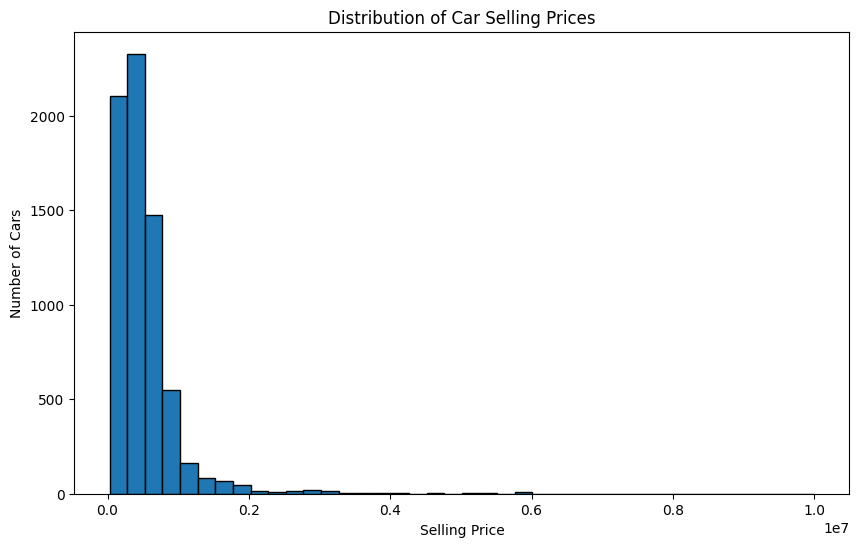

In [89]:
# Chart 1: Distribution of Selling Price

plt.figure(figsize=(10, 6))

plt.hist(clean_df['selling_price'], bins=40, edgecolor='black')

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

**Observation:** The selling price distribution is concentrated toward the lower price range, with fewer vehicles at substantially higher prices. This indicates that the dataset contains some high-priced observations.

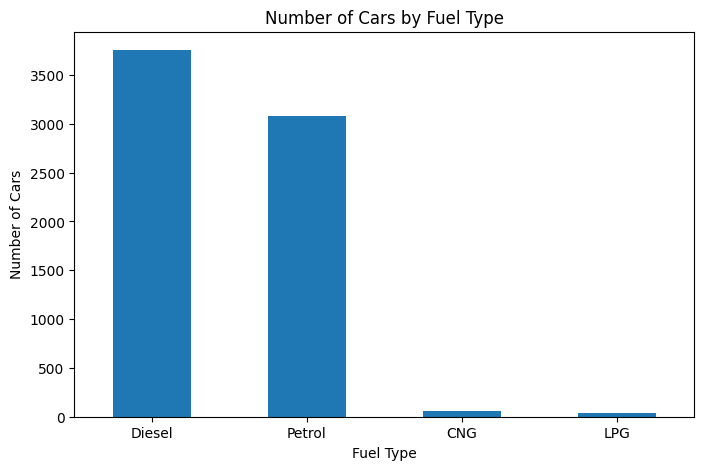

In [90]:
# Chart 2: Cars by Fuel Type

plt.figure(figsize=(8, 5))

clean_df['fuel'].value_counts().plot(kind='bar')

plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')

plt.xticks(rotation=0)
plt.show()

**Observation:** Diesel cars form the largest group in the dataset, followed by petrol cars. CNG and LPG vehicles represent much smaller portions of the dataset.

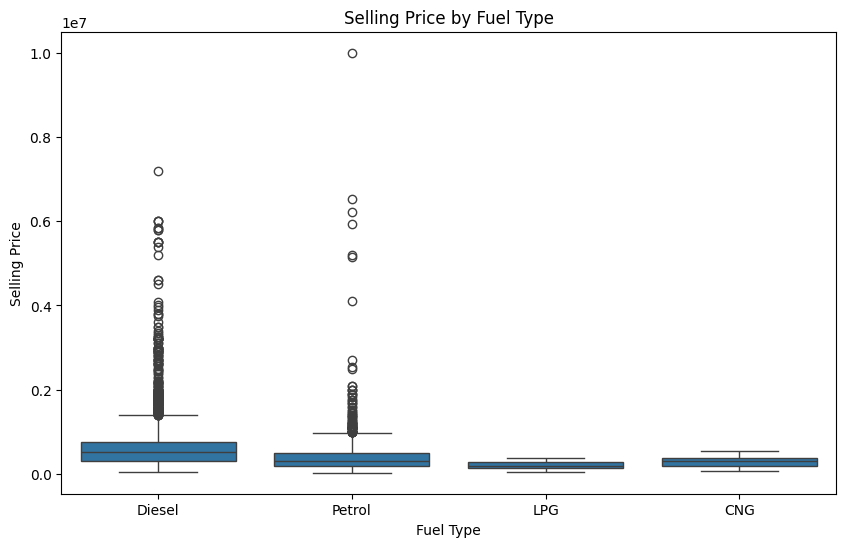

In [91]:
# Chart 3: Selling Price by Fuel Type

plt.figure(figsize=(10, 6))

sns.boxplot(data=clean_df, x='fuel', y='selling_price')

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

**Observation:** The box plot shows differences in selling-price distributions across fuel types and also reveals high-price observations within some categories.

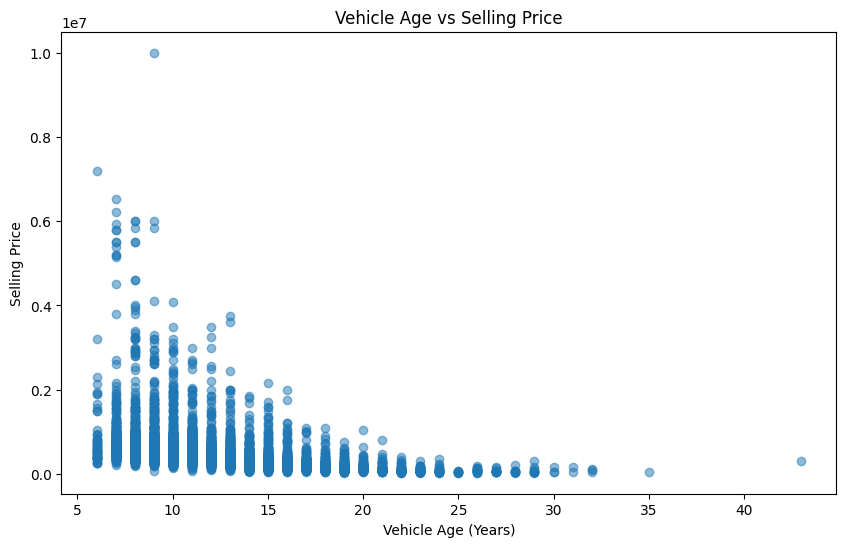

In [92]:
# Chart 4: Vehicle Age vs Selling Price

plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['vehicle_age'],
    clean_df['selling_price'],
    alpha=0.5
)

plt.title('Vehicle Age vs Selling Price')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Selling Price')

plt.show()

**Observation:** The scatter plot indicates that selling prices generally tend to be lower for older vehicles, although the relationship is not perfectly uniform.

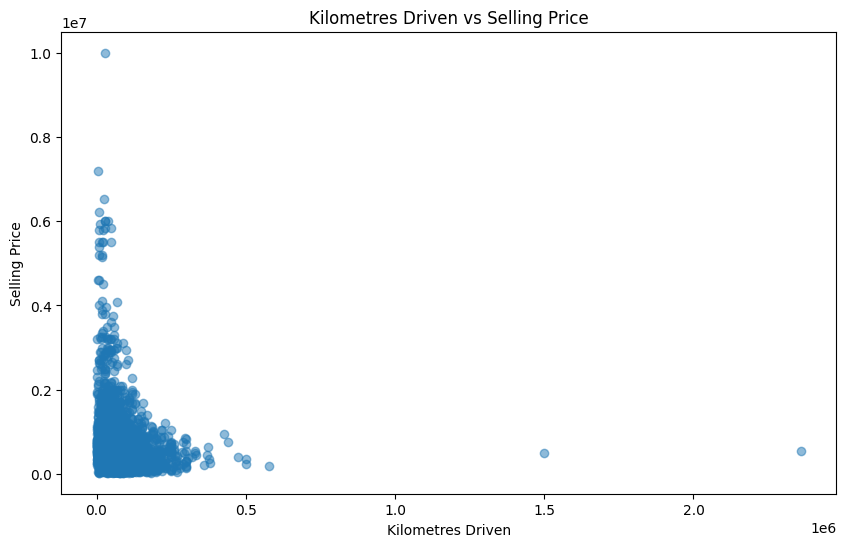

In [93]:
# Chart 5: Kilometres Driven vs Selling Price

plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['km_driven'],
    clean_df['selling_price'],
    alpha=0.5
)

plt.title('Kilometres Driven vs Selling Price')
plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price')

plt.show()

**Observation:** Cars with higher kilometres driven generally show lower selling prices, although considerable variation exists between individual vehicles.

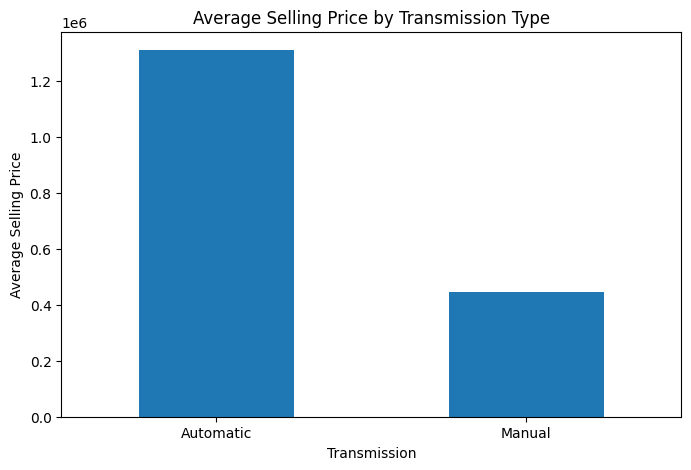

In [94]:
# Chart 6: Average Selling Price by Transmission

average_price_transmission = (
    clean_df.groupby('transmission')['selling_price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

average_price_transmission.plot(kind='bar')

plt.title('Average Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')

plt.xticks(rotation=0)
plt.show()

**Observation:** Automatic cars have a substantially higher average selling price than manual cars in this dataset.

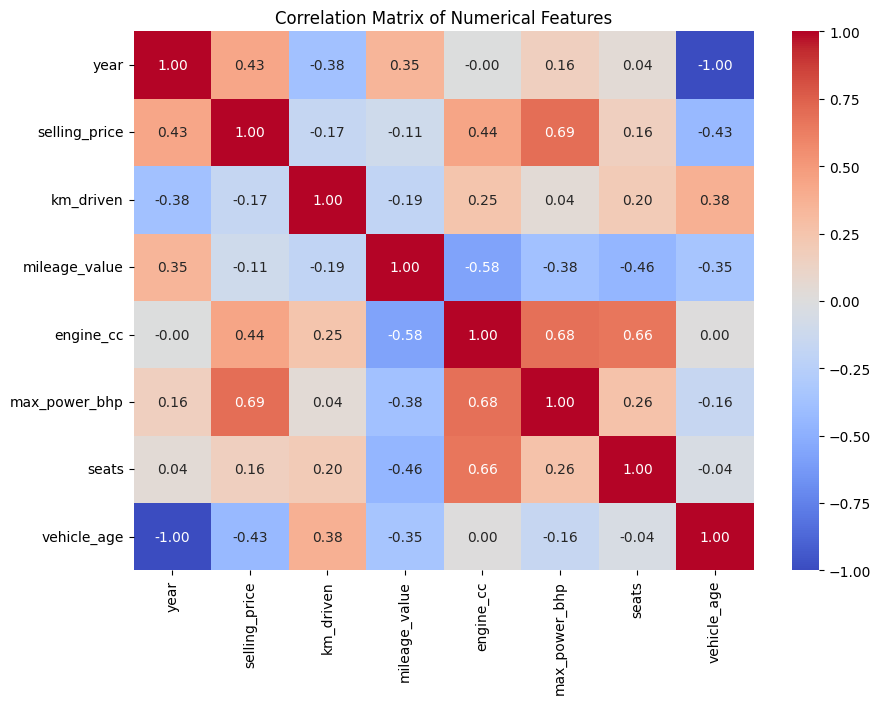

In [95]:
# Chart 7: Correlation Heatmap

correlation_columns = [
    'year',
    'selling_price',
    'km_driven',
    'mileage_value',
    'engine_cc',
    'max_power_bhp',
    'seats',
    'vehicle_age'
]

correlation_matrix = clean_df[correlation_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

**Observation:** The correlation heatmap shows the strength and direction of relationships among the numerical variables. Selling price has noticeable relationships with several vehicle characteristics, which can be examined further.

## 8. Outlier Analysis

In [96]:
# Outlier analysis for selling price

Q1 = clean_df['selling_price'].quantile(0.25)
Q3 = clean_df['selling_price'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

price_outliers = clean_df[
    (clean_df['selling_price'] < lower_limit) |
    (clean_df['selling_price'] > upper_limit)
]

print("Selling Price Outlier Analysis")
print("--------------------------------")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(price_outliers))

Selling Price Outlier Analysis
--------------------------------
Q1: 250000.0
Q3: 633500.0
IQR: 383500.0
Lower Limit: -325250.0
Upper Limit: 1208750.0
Number of Outliers: 328


In [97]:
# Highest-priced cars

clean_df[
    ['name', 'year', 'selling_price', 'fuel', 'transmission']
].sort_values(
    by='selling_price',
    ascending=False
).head(10)

,name,year,selling_price,fuel,transmission
170,Volvo XC90 T8 Excellence BSIV,2017,10000000,Petrol,Automatic
2938,BMW X7 xDrive 30d DPE,2020,7200000,Diesel,Automatic
4952,Audi A6 35 TFSI Matrix,2019,6523000,Petrol,Automatic
4950,Audi A6 35 TFSI Matrix,2019,6223000,Petrol,Automatic
4766,BMW 6 Series GT 630d Luxury Line,2018,6000000,Diesel,Automatic
136,Mercedes-Benz S-Class S 350 CDI,2017,6000000,Diesel,Automatic
1071,BMW 6 Series GT 630d Luxury Line,2018,6000000,Diesel,Automatic
4951,Audi A6 35 TFSI Matrix,2019,5923000,Petrol,Automatic
148,Mercedes-Benz S-Class S 350 CDI,2017,5850000,Diesel,Automatic
6258,BMW 6 Series GT 630d Luxury Line,2018,5830000,Diesel,Automatic


In [98]:
# Outlier analysis for kilometres driven

Q1_km = clean_df['km_driven'].quantile(0.25)
Q3_km = clean_df['km_driven'].quantile(0.75)

IQR_km = Q3_km - Q1_km

lower_km = Q1_km - 1.5 * IQR_km
upper_km = Q3_km + 1.5 * IQR_km

km_outliers = clean_df[
    (clean_df['km_driven'] < lower_km) |
    (clean_df['km_driven'] > upper_km)
]

print("Kilometres Driven Outlier Analysis")
print("-----------------------------------")
print("Lower Limit:", lower_km)
print("Upper Limit:", upper_km)
print("Number of Outliers:", len(km_outliers))

Kilometres Driven Outlier Analysis
-----------------------------------
Lower Limit: -50000.0
Upper Limit: 190000.0
Number of Outliers: 167


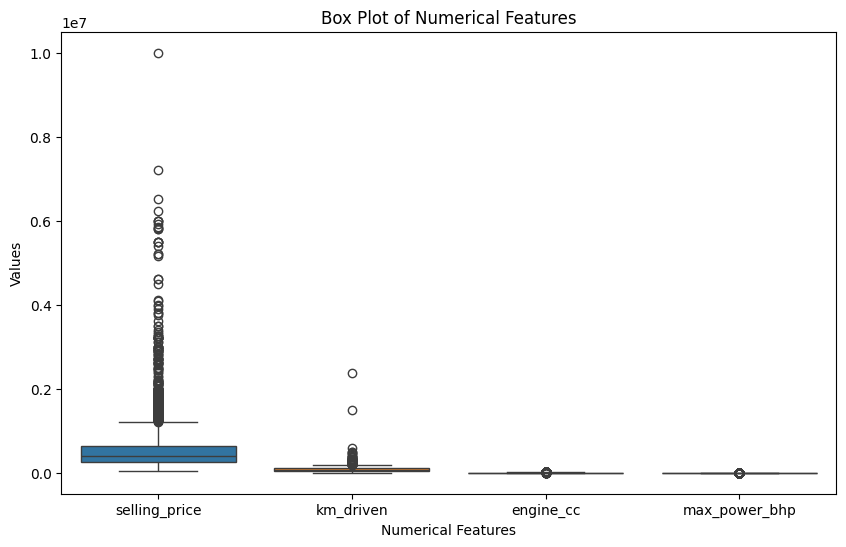

In [99]:
# Box plot for important numerical variables

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df[
        ['selling_price', 'km_driven', 'engine_cc', 'max_power_bhp']
    ]
)

plt.title('Box Plot of Numerical Features')
plt.xlabel('Numerical Features')
plt.ylabel('Values')

plt.show()

## 9. Key Findings

In [100]:
# Final key statistics for the report

print("FINAL PROJECT STATISTICS")
print("========================")

print("Total records after cleaning:", len(clean_df))
print("Total features:", clean_df.shape[1])

print("\nMost common fuel type:")
print(clean_df['fuel'].value_counts().idxmax())

print("\nMost common transmission:")
print(clean_df['transmission'].value_counts().idxmax())

print("\nMedian selling price:")
print(clean_df['selling_price'].median())

print("\nMean selling price:")
print(round(clean_df['selling_price'].mean(), 2))

print("\nAverage price by transmission:")
print(clean_df.groupby('transmission')['selling_price'].mean())

print("\nAverage price by fuel:")
print(clean_df.groupby('fuel')['selling_price'].mean().sort_values(ascending=False))

FINAL PROJECT STATISTICS
Total records after cleaning: 6926
Total features: 17

Most common fuel type:
Diesel

Most common transmission:
Manual

Median selling price:
400000.0

Mean selling price:
517270.68

Average price by transmission:
transmission
Automatic    1.309712e+06
Manual       4.442991e+05
Name: selling_price, dtype: float64

Average price by fuel:
fuel
Diesel    639727.768842
Petrol    375688.966526
CNG       300499.946429
LPG       200421.052632
Name: selling_price, dtype: float64


1. The cleaned dataset contains 6,926 vehicle records after removing 1,202 exact duplicate records.

2. Diesel is the most common fuel type, with 3,755 records, followed by petrol with 3,077 records.

3. The median selling price is ₹4,00,000, while the mean selling price is approximately ₹5,17,271, indicating that higher-priced vehicles influence the average.

4. Automatic vehicles have a substantially higher average selling price than manual vehicles in this dataset.

5. Vehicle age and selling price show a general negative relationship, with older vehicles tending to have lower selling prices.

6. Kilometres driven also shows a general negative relationship with selling price, although the relationship varies across individual vehicles.

7. The dataset contains high-value and high-mileage observations that should be treated as potential outliers rather than automatically removed.

## 10. Limitations

- The dataset contains used-car listings and may not represent the complete automobile market.
- Some numerical attributes were originally stored as text with measurement units.
- The dataset contains duplicate records, which were removed during cleaning.
- Some attributes contain missing values and were treated using median imputation.
- The analysis identifies relationships in the dataset but does not establish causal relationships.
- The dataset contains a large number of different car models, so model-level comparisons may have uneven sample sizes.

## 11. Conclusion

The exploratory data analysis provided an understanding of the characteristics and pricing patterns of used cars in the dataset. The data was inspected and cleaned by removing duplicate records, converting text-based numerical attributes into usable numerical variables, and treating missing numerical values. Descriptive statistics and visualizations were then used to study price distribution, fuel types, transmission, vehicle age, kilometres driven, and relationships among numerical variables.

The analysis showed that the dataset is dominated by diesel and petrol vehicles, while automatic vehicles have a substantially higher average selling price than manual vehicles. The analysis also identified general relationships between vehicle age, kilometres driven, and selling price, along with several potential outliers.

Overall, the project demonstrates how Exploratory Data Analysis can be used to clean automobile data, discover meaningful patterns, identify unusual observations, and communicate findings through statistical analysis and visualizations.